# Export Results

Create an `Excel file` that includes the predictions from both methods with their respective set of marker genes.

In [1]:
from pathlib import Path

import anndata as ad
import decoupler as dc
import pandas as pd
import scanpy as sc

/home/ubuntu/software/miniforge3/envs/liver-sc-imputation/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
data_dir = Path("../output/cell_type_annotation_ST")
data_dir

PosixPath('../output/cell_type_annotation_ST')

## Prepare Markers

In [3]:
markers = pd.read_feather(data_dir / "pdata_marker_genes.feather")
markers

,0,1,2,3,4,5,6,7,8,9,10
0,Cd55,Dbi,Glul,Malat1,Malat1,Cnksr2,C1qc,Dcn,Tmsb4x,Spp1,Tubb5
1,Igfbp7,Ugt8a,Slc1a2,Vegfa,Hc,Nrsn1,C1qb,Igfbp7,Tmsb10,Clu,H3f3b
2,Kdr,Scg2,Rgn,Gcgr,Cfh,Cd6,C1qa,Col3a1,Ptprc,Atp1b1,Ldha
3,Esam,Ctnna2,Gstm1,Rgn,Aldh1l1,Gsn,Tmsb4x,Col1a2,Cd74,Tmsb10,Hsp90ab1
4,Pecam1,Cnksr2,Slc13a3,Lpin1,Vtn,Cxcl2,Ctss,Reln,H2-Aa,Pdgfd,Hspa8
...,...,...,...,...,...,...,...,...,...,...,...
946,Lpin1,Fus,Sparc,Msr1,Glul,Fth1,Clu,Gjb1,Fn1,Hc,Ednrb
947,H6pd,Serinc3,Mt1,Pecam1,Dcn,B2m,Lpin1,Ttr,Crp,Ttr,Ctss
948,Gcgr,Tmsb4x,Msr1,Sparc,Tmsb4x,Ftl1,Gcgr,Aldh1l1,Clu,Ftl1,Pecam1
949,Crp,Hnrnpa2b1,Serinc3,Igfbp7,Igfbp7,Ttr,Crp,Crp,H6pd,Rgn,Rgl1


In [5]:
top30 = markers[0:30]
top30

,0,1,2,3,4,5,6,7,8,9,10
0,Cd55,Dbi,Glul,Malat1,Malat1,Cnksr2,C1qc,Dcn,Tmsb4x,Spp1,Tubb5
1,Igfbp7,Ugt8a,Slc1a2,Vegfa,Hc,Nrsn1,C1qb,Igfbp7,Tmsb10,Clu,H3f3b
2,Kdr,Scg2,Rgn,Gcgr,Cfh,Cd6,C1qa,Col3a1,Ptprc,Atp1b1,Ldha
3,Esam,Ctnna2,Gstm1,Rgn,Aldh1l1,Gsn,Tmsb4x,Col1a2,Cd74,Tmsb10,Hsp90ab1
4,Pecam1,Cnksr2,Slc13a3,Lpin1,Vtn,Cxcl2,Ctss,Reln,H2-Aa,Pdgfd,Hspa8
5,Tspan7,Pak3,Comt,Crp,Crp,Nos1,Tyrobp,Sparc,H2-Ab1,Sox9,Rps9
6,Plpp3,Gria1,Rbp4,Hnrnpa2b1,Gcgr,Pou2f1,Csf1r,Tmsb10,Tyrobp,Timp2,Ywhaz
7,Serinc3,Htr2c,Ghr,Hc,Vegfa,Drd4,Ctsb,Pdgfra,Samhd1,App,Hsp90aa1
8,Fyn,Grid2,Lgr5,Ghr,C3,Tiam1,Axl,Timp2,Srgn,Mfge8,Hnrnpa2b1
9,Flt1,Dgkb,Sod1,Gjb1,Hnf4a,Tacr1,Msr1,Gsn,Vim,Ppp1r1b,Cdkn1a


## Extract Annotations

In [8]:
ct_cluster_map = pd.read_feather("../figures/data/pdata_ct_cluster_mapping.feather")
ct_cluster_map

,cluster,celltypist,manual_t15,manual_t30,panglaodb
0,0,Endothelial cells,Fibroblasts,Fibroblasts,Hepatic stellate cells
1,1,Endothelial cells,Hepatocytes_3,Cholangiocytes,Cholangiocytes
2,2,Endothelial cells,Hepatocytes_3,Hepatocytes_3,Hepatocytes
3,3,Hepatocytes,Hepatocytes_3,Hepatocytes_3,Hepatocytes
4,4,Endothelial cells,Hepatocytes_5,Hepatocytes_2,Hepatoblasts
5,5,Endothelial cells,T-cells_3,T-cells_3,Cholangiocytes
6,6,Kupffer cells,Kupffer_1,Kupffer_1,Kupffer cells
7,7,Fibroblasts,Fibroblasts,Smooth muscle cells,Hepatic stellate cells
8,8,Endothelial cells,Kupffer_3,Kupffer_3,Kupffer cells
9,9,Endothelial cells,Cholangiocytes,Cholangiocytes,Cholangiocytes


In [9]:
ct_cluster_map = ct_cluster_map.set_index("cluster")
ct_cluster_map.index.name = None
ct_cluster_map.transpose()

,0,1,2,3,4,5,6,7,8,9,10
celltypist,Endothelial cells,Endothelial cells,Endothelial cells,Hepatocytes,Endothelial cells,Endothelial cells,Kupffer cells,Fibroblasts,Endothelial cells,Endothelial cells,Endothelial cells
manual_t15,Fibroblasts,Hepatocytes_3,Hepatocytes_3,Hepatocytes_3,Hepatocytes_5,T-cells_3,Kupffer_1,Fibroblasts,Kupffer_3,Cholangiocytes,Erythroid
manual_t30,Fibroblasts,Cholangiocytes,Hepatocytes_3,Hepatocytes_3,Hepatocytes_2,T-cells_3,Kupffer_1,Smooth muscle cells,Kupffer_3,Cholangiocytes,Plasma cells
panglaodb,Hepatic stellate cells,Cholangiocytes,Hepatocytes,Hepatocytes,Hepatoblasts,Cholangiocytes,Kupffer cells,Hepatic stellate cells,Kupffer cells,Cholangiocytes,Hepatoblasts


## Prepare Excel File

In [7]:
save_dir = data_dir / "results_summary"
save_dir.mkdir(parents=True, exist_ok=True)
save_dir

PosixPath('../output/cell_type_annotation_ST/results_summary')

In [8]:
# Dictionary of DataFrames where keys are sheet names
dfs = {"Cell Type Annotation": ct_cluster_map, "Curated Marker Genes": top30}

# Save to an Excel file
with pd.ExcelWriter(
    save_dir / "cell_type_annotation.xlsx", engine="openpyxl"
) as writer:
    for sheet_name, df in dfs.items():
        df.to_excel(writer, sheet_name=sheet_name, index=False)

In [9]:
ref_markers = dc.get_resource(name="PanglaoDB", organism="mouse", license="academic")
ref_markers.head()

,genesymbol,canonical_marker,cell_type,germ_layer,human,human_sensitivity,human_specificity,mouse,mouse_sensitivity,mouse_specificity,ncbi_tax_id,organ,ubiquitiousness
0,Ctrb1,False,Enterocytes,Endoderm,True,0.0,0.004394,True,0.003311,0.020480,9606,GI tract,0.017
1,Ctrb1,True,Acinar cells,Endoderm,True,1.0,0.000629,True,0.957143,0.015920,9606,Pancreas,0.017
2,Klk1b24,True,Endothelial cells,Mesoderm,True,0.0,0.008420,True,0.000000,0.014915,9606,Vasculature,0.013
3,Klk1b1,True,Endothelial cells,Mesoderm,True,0.0,0.008420,True,0.000000,0.014915,9606,Vasculature,0.013
4,Klk1b26,True,Endothelial cells,Mesoderm,True,0.0,0.008420,True,0.000000,0.014915,9606,Vasculature,0.013


In [10]:
filtered_ref = ref_markers[
    (ref_markers["mouse"] == True) & (ref_markers["organ"] == "Liver")
]
filtered_ref.head()

,genesymbol,canonical_marker,cell_type,germ_layer,human,human_sensitivity,human_specificity,mouse,mouse_sensitivity,mouse_specificity,ncbi_tax_id,organ,ubiquitiousness
191,Lgals2,True,Cholangiocytes,Endoderm,True,0.133333,0.035611,True,1.0,0.030675,9606,Liver,0.032
208,<NA>,True,Hepatocytes,Endoderm,True,0.054054,0.009192,True,0.2,0.006047,9606,Liver,0.007
209,<NA>,True,Hepatocytes,Endoderm,True,0.054054,0.009192,True,0.2,0.006047,9606,Liver,0.007
210,Gsta1,True,Hepatocytes,Endoderm,True,0.054054,0.009192,True,0.2,0.006047,9606,Liver,0.007
211,Gsta2,True,Hepatocytes,Endoderm,True,0.054054,0.009192,True,0.2,0.006047,9606,Liver,0.007


In [11]:
result = {}
for cell_type in filtered_ref["cell_type"].unique():
    cell_markers = filtered_ref[filtered_ref["cell_type"] == cell_type]
    top_5 = cell_markers.head(5)["genesymbol"].tolist()
    result[cell_type] = top_5

result

{'Cholangiocytes': ['Lgals2', 'Aqp1', <NA>, 'Scgb3a1', 'Agr2'],
 'Hepatocytes': [<NA>, <NA>, 'Gsta1', 'Gsta2', 'Cebpa'],
 'Hepatoblasts': ['Cebpa', <NA>, 'Hhex', 'Krt14', <NA>],
 'Hepatic stellate cells': ['Fgf10', <NA>, 'Timp1', 'Acta2', 'Foxf1'],
 'Kupffer cells': ['Tlr4', 'Ifi204', 'Mndal', 'Ifi205a', 'Il1b']}

In [36]:
adata = ad.read_h5ad(data_dir / "liver_merged.h5ad")
adata

AnnData object with n_obs × n_vars = 67785 × 951
    obs: 'counts_per_cell', 'non_zero_features', 'cell_id', 'disease_state', 'slide', 'tissue', 'fov', '_scvi_batch', '_scvi_labels', 'scVI_leiden', 'scVI_norm_leiden', 'CT_predictions', 'CT_majority', 'PDB_predictions', 'manual_prediction_top15', 'manual_prediction_top30'
    var: 'counts_per_gene', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'PDB_predictions_colors', '_scvi_manager_uuid', '_scvi_uuid', 'disease_state_colors', 'hvg', 'log1p', 'manual_prediction_top15_colors', 'manual_prediction_top30_colors', 'neighbors', 'pca', 'rank_genes_groups', 'scVI_leiden', 'scVI_neighbors', 'scVI_norm_leiden', 'scVI_norm_neighbors', 'slide_colors', 'umap'
    obsm: 'X_pca', 'X_scVI', 'X_umap', '_scvi_extra_categorical_covs', 'log1p_pca', 'log1p_umap', 'ora_estimate', 'ora_pvals', 'scVI_norm_pca', 'scVI_norm_umap', 'scVI_umap'
    varm: 'PCs'
    layers: 'CellTypist_normalized', 'log1p', 'raw', 'scVI

In [57]:
all_markers = [gene for marker_list in result.values() for gene in marker_list]
found_markers = adata.var_names.isin(all_markers)
found_feature_names = adata.var_names[found_markers].tolist()

found_feature_names

['Acta2', 'Il1b', 'Tlr4']

No marker information can be provided

In [13]:
ct_cluster_map

,celltypist,manual_t15,manual_t30,panglaodb
0,Endothelial cells,Fibroblasts,Fibroblasts,Hepatic stellate cells
1,Endothelial cells,Hepatocytes_3,Cholangiocytes,Cholangiocytes
2,Endothelial cells,Hepatocytes_3,Hepatocytes_3,Hepatocytes
3,Hepatocytes,Hepatocytes_3,Hepatocytes_3,Hepatocytes
4,Endothelial cells,Hepatocytes_5,Hepatocytes_2,Hepatoblasts
5,Endothelial cells,T-cells_3,T-cells_3,Cholangiocytes
6,Kupffer cells,Kupffer_1,Kupffer_1,Kupffer cells
7,Fibroblasts,Fibroblasts,Smooth muscle cells,Hepatic stellate cells
8,Endothelial cells,Kupffer_3,Kupffer_3,Kupffer cells
9,Endothelial cells,Cholangiocytes,Cholangiocytes,Cholangiocytes


In [11]:
ct_cluster_map["consensus"] = [
    "Fibroblasts",
    "Cholangiocytes",
    "Hepatocytes",
    "Hepatocytes",
    "Hepatocytes",
    "T cells",
    "Kupffer cells",
    "Hepatic stellate cells",
    "Kupffer cells",
    "Cholangiocytes",
    "Hepatoblasts",
]

In [18]:
top3 = top30.head(3).transpose()
top3["annotation"] = ct_cluster_map["consensus"]

top3 = top3.set_index("annotation")
top3.index.name = None
top3 = top3.sort_index()

top3.to_feather(data_dir / "cell_type_markers.feather")
top3

,0,1,2
Cholangiocytes,Dbi,Ugt8a,Scg2
Cholangiocytes,Spp1,Clu,Atp1b1
Fibroblasts,Cd55,Igfbp7,Kdr
Hepatic stellate cells,Dcn,Igfbp7,Col3a1
Hepatoblasts,Tubb5,H3f3b,Ldha
Hepatocytes,Glul,Slc1a2,Rgn
Hepatocytes,Malat1,Vegfa,Gcgr
Hepatocytes,Malat1,Hc,Cfh
Kupffer cells,C1qc,C1qb,C1qa
Kupffer cells,Tmsb4x,Tmsb10,Ptprc


In [35]:
mapping = (
    top3.groupby(top3.index).apply(lambda g: set(g.values.ravel().tolist())).to_dict()
)

mapping

{'Cholangiocytes': {'Atp1b1', 'Clu', 'Dbi', 'Scg2', 'Spp1', 'Ugt8a'},
 'Fibroblasts': {'Cd55', 'Igfbp7', 'Kdr'},
 'Hepatic stellate cells': {'Col3a1', 'Dcn', 'Igfbp7'},
 'Hepatoblasts': {'H3f3b', 'Ldha', 'Tubb5'},
 'Hepatocytes': {'Cfh',
  'Gcgr',
  'Glul',
  'Hc',
  'Malat1',
  'Rgn',
  'Slc1a2',
  'Vegfa'},
 'Kupffer cells': {'C1qa', 'C1qb', 'C1qc', 'Ptprc', 'Tmsb10', 'Tmsb4x'},
 'T cells': {'Cd6', 'Cnksr2', 'Nrsn1'}}

In [43]:
# Outdated
cell_type_markers = {
    "Cholangiocytes": ["Sox9", "Sstr2", "Cxcl2"],
    "Endothelial cells": ["Pecam1", "Cldn5", "Kdr", "Srgn"],
    "Erythroids": ["Cd55", "S100a8", "Epb41l2"],
    "Fibroblasts": ["Pdgfra", "Pdgfrb", "Col1a1", "Col1a2", "Col3a1"],
    "Stellate cells": ["Reln", "Dcn"],
    "Hepatoblasts": ["Map2k4", "Hnf4a"],
    "Hepatocytes": ["Crp", "Bche", "Lepr"],
    "Kupffer cells": ["C1qa", "C1qc", "Csf1r", "Msr1", "Pltp"],
    "Smooth muscle cells": ["Acta2", "Rgs5", "Tagln", "Fbln5"],
    "T cells": ["Sema6d", "Thy1", "Cd3e", "Cd3g", "Cd3d"],
}

cell_type_markers = pd.DataFrame.from_dict(
    cell_type_markers,
    orient="index",
)

# cell_type_markers.to_feather(data_dir / "cell_type_markers.feather")
cell_type_markers

,0,1,2,3,4
Cholangiocytes,Sox9,Sstr2,Cxcl2,None,None
Endothelial cells,Pecam1,Cldn5,Kdr,Srgn,None
Erythroids,Cd55,S100a8,Epb41l2,None,None
Fibroblasts,Pdgfra,Pdgfrb,Col1a1,Col1a2,Col3a1
Stellate cells,Reln,Dcn,None,None,None
Hepatoblasts,Map2k4,Hnf4a,None,None,None
Hepatocytes,Crp,Bche,Lepr,None,None
Kupffer cells,C1qa,C1qc,Csf1r,Msr1,Pltp
Smooth muscle cells,Acta2,Rgs5,Tagln,Fbln5,None
T cells,Sema6d,Thy1,Cd3e,Cd3g,Cd3d


In [ ]:
ct_markers_flat = list(set(cell_type_markers.values.flatten().tolist()))
ct_markers_flat

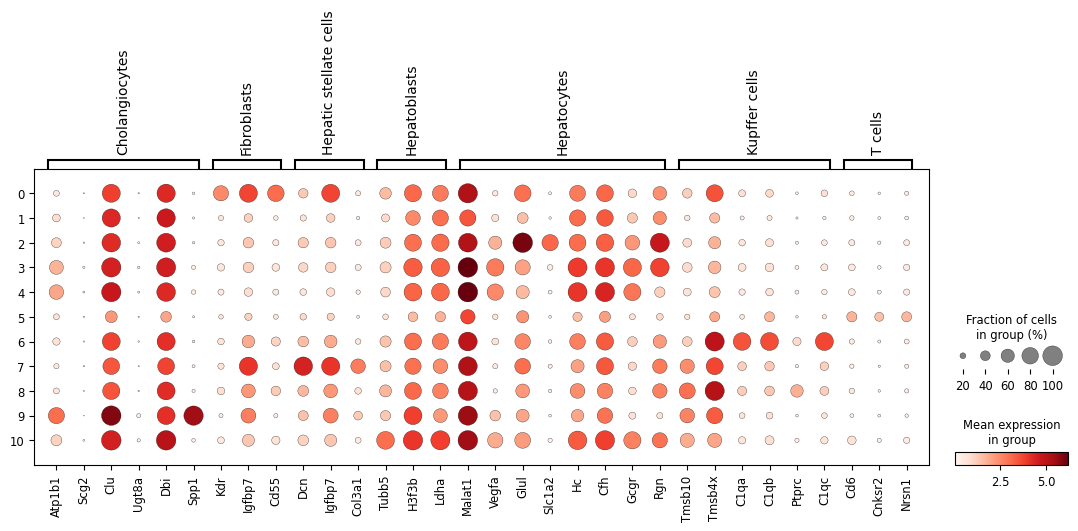

In [37]:
sc.pl.dotplot(
    adata,
    var_names=mapping,
    groupby="scVI_leiden",
    save="top3_marker.svg",
)